<a href="https://colab.research.google.com/github/iamhero2709/Airline-Sentiment-Analysis/blob/main/Twiter_US_airline_sentiment_anlysios_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install all dependencies
!pip install nltk tensorflow transformers pandas matplotlib
!pip install tensorflow==2.13.0 --upgrade
!pip install transformers --upgrade
!pip install numpy==1.25.0
!pip install tensorflow==2.13.0
!pip install --upgrade jaxlib jax


  Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.5.3 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
jaxlib 0.5.3 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
pymc 5.21.2 requires numpy>=1.25.0, but you have numpy 1.24.3 which is incompatible.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.13.0 which is incompatible.
tf-keras 2.18.0 requires tensorflow<2.19,>=2.18, but you have tensorflow 2.13.0 which is incompatible.
nibabel 5.3.

  Using cached numpy-1.25.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.25.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.13.0 requires numpy<=1.24.3,>=1.22, but you have numpy 1.25.0 which is incompatible.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.13.0 which is incompatible.
tf-keras 2.18.0 requires tensorflow<2.19,>=2.18, but you have tensorflow 2.13.0 which is incompatible.
nibabel 5.3.2 requires typing-extensions>=4.6; python_version < "3.13", but you have typing-extensions 4.5.0 which is incompatible.
treescope 0.1.9 requires nump

  Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.25.0
    Uninstalling numpy-1.25.0:
      Successfully uninstalled numpy-1.25.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.5.3 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
jaxlib 0.5.3 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
pymc 5.21.2 requires numpy>=1.25.0, but you have numpy 1.24.3 which is incompatible.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.13.0 which is incompatible.
tf-keras 2.18.0 requires tensorflow<2.19,>=2.18, but you have tensorflow 2.13.0 which is incompatible.
nibabel 5

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.13.0 requires numpy<=1.24.3,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.13.0 which is incompatible.
tf-keras 2.18.0 requires tensorflow<2.19,>=2.18, but you have tensorflow 2.13.0 which is incompatible.
nibabel 5.3.2 requires typing-extensions>=4.6; python_version < "3.13", but you have typing-extensions 4.5.0 which is incompatible.
numba 0.60.0 requires numpy<2.1,>

In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import re
from nltk.corpus import stopwords
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from nltk.sentiment import SentimentIntensityAnalyzer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder


In [43]:
df = pd.read_csv('/content/Tweets.csv') # Forward slashes

In [44]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [45]:
df.shape

(14640, 15)

In [46]:
df.isnull()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,False,False,False,True,True,False,True,False,True,False,False,True,False,True,False
1,False,False,False,True,False,False,True,False,True,False,False,True,False,True,False
2,False,False,False,True,True,False,True,False,True,False,False,True,False,False,False
3,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False
4,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,False,False,False,True,False,False,True,False,True,False,False,True,False,True,True
14636,False,False,False,False,False,False,True,False,True,False,False,True,False,False,True
14637,False,False,False,True,True,False,True,False,True,False,False,True,False,False,True
14638,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False


In [47]:
print(df.isnull().sum())


tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64


In [48]:
df_cleaned_cols = df.dropna(axis=1)
print(df_cleaned_cols)



                 tweet_id airline_sentiment  airline_sentiment_confidence  \
0      570306133677760513           neutral                        1.0000   
1      570301130888122368          positive                        0.3486   
2      570301083672813571           neutral                        0.6837   
3      570301031407624196          negative                        1.0000   
4      570300817074462722          negative                        1.0000   
...                   ...               ...                           ...   
14635  569587686496825344          positive                        0.3487   
14636  569587371693355008          negative                        1.0000   
14637  569587242672398336           neutral                        1.0000   
14638  569587188687634433          negative                        1.0000   
14639  569587140490866689           neutral                        0.6771   

              airline             name  retweet_count  \
0      Virgin Amer

In [49]:
df.isnull()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,False,False,False,True,True,False,True,False,True,False,False,True,False,True,False
1,False,False,False,True,False,False,True,False,True,False,False,True,False,True,False
2,False,False,False,True,True,False,True,False,True,False,False,True,False,False,False
3,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False
4,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,False,False,False,True,False,False,True,False,True,False,False,True,False,True,True
14636,False,False,False,False,False,False,True,False,True,False,False,True,False,False,True
14637,False,False,False,True,True,False,True,False,True,False,False,True,False,False,True
14638,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False


In [50]:
print(df.isnull().sum())


tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64


In [51]:
df.drop(columns=[
    'tweet_coord',          # 13,621/14,640 null (93% missing)
    'negativereason_gold',  # 14,608/14,640 null (~99.8% missing)
    'airline_sentiment_gold'# 14,600/14,640 null (~99.7% missing)
], inplace=True)

In [52]:
print(df.isnull().sum())

tweet_id                           0
airline_sentiment                  0
airline_sentiment_confidence       0
negativereason                  5462
negativereason_confidence       4118
airline                            0
name                               0
retweet_count                      0
text                               0
tweet_created                      0
tweet_location                  4733
user_timezone                   4820
dtype: int64


In [53]:
# For 'negativereason' (5,462 nulls)
df['negativereason'] = df['negativereason'].fillna('Not Specified')

# For 'negativereason_confidence' (4,118 nulls)
# Fill with 0 when reason is missing, otherwise with mean
df['negativereason_confidence'] = np.where(
    df['negativereason'] == 'Not Specified',
    0,
    df['negativereason_confidence'].fillna(df['negativereason_confidence'].mean())
)

In [54]:
# For tweet_location (4,733 nulls) and user_timezone (4,820 nulls)
df['tweet_location'] = df['tweet_location'].fillna('Unknown')
df['user_timezone'] = df['user_timezone'].fillna('Unknown')


In [55]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,Not Specified,0.0000,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800,Unknown,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,Not Specified,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59 -0800,Unknown,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,Not Specified,0.0000,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36 -0800,Unknown,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45 -0800,Unknown,Pacific Time (US & Canada)


In [56]:

def clean_tweet_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove user mentions and hashtags (keep text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)



    # Remove special chars (keep letters and basic punctuation)
    text = re.sub(r'[^\w\s.,!?]', '', text)

    # Convert to lowercase
    text = text.lower()

    return text.strip()

df['cleaned_text'] = df['text'].apply(clean_tweet_text)

In [57]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,tweet_location,user_timezone,cleaned_text
0,570306133677760513,neutral,1.0000,Not Specified,0.0000,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800,Unknown,Eastern Time (US & Canada),what said.
1,570301130888122368,positive,0.3486,Not Specified,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59 -0800,Unknown,Pacific Time (US & Canada),plus youve added commercials to the experience...
2,570301083672813571,neutral,0.6837,Not Specified,0.0000,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada),i didnt today... must mean i need to take anot...
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36 -0800,Unknown,Pacific Time (US & Canada),its really aggressive to blast obnoxious enter...
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45 -0800,Unknown,Pacific Time (US & Canada),and its a really big bad thing about it


FEATURE ENGINEERING

In [58]:
# TWEET LEANGTH FEATURE
df['tweet_length']=df['cleaned_text'].apply(len)

# time features
df['tweet_created']=pd.to_datetime(df['tweet_created'])
df['tweet_hour'] = df['tweet_created'].dt.hour
df['tweet_day_of_week'] = df['tweet_created'].dt.day_name()

In [59]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,tweet_location,user_timezone,cleaned_text,tweet_length,tweet_hour,tweet_day_of_week
0,570306133677760513,neutral,1.0000,Not Specified,0.0000,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52-08:00,Unknown,Eastern Time (US & Canada),what said.,11,11,Tuesday
1,570301130888122368,positive,0.3486,Not Specified,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59-08:00,Unknown,Pacific Time (US & Canada),plus youve added commercials to the experience...,56,11,Tuesday
2,570301083672813571,neutral,0.6837,Not Specified,0.0000,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48-08:00,Lets Play,Central Time (US & Canada),i didnt today... must mean i need to take anot...,55,11,Tuesday
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36-08:00,Unknown,Pacific Time (US & Canada),its really aggressive to blast obnoxious enter...,105,11,Tuesday
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45-08:00,Unknown,Pacific Time (US & Canada),and its a really big bad thing about it,39,11,Tuesday


AIRLINE SPECIFIC FEATURE

In [60]:

# Airline mention frequency
airlines = ['VirginAmerica', 'United', 'Southwest', 'Delta', 'American']
for airline in airlines:
    df[f'mentions_{airline}'] = df['text'].str.contains(airline, case=False).astype(int)

In [61]:
df.isnull().sum()

,0
tweet_id,0
airline_sentiment,0
airline_sentiment_confidence,0
negativereason,0
negativereason_confidence,0
airline,0
name,0
retweet_count,0
text,0
tweet_created,0


# **EDA **

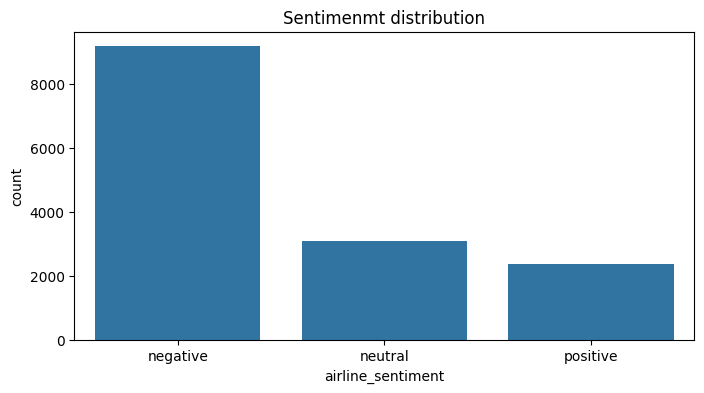

In [62]:
 # sentimnet distrinbution
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='airline_sentiment', order=['negative', 'neutral', 'positive'])
plt.title("Sentimenmt distribution")
plt.show()

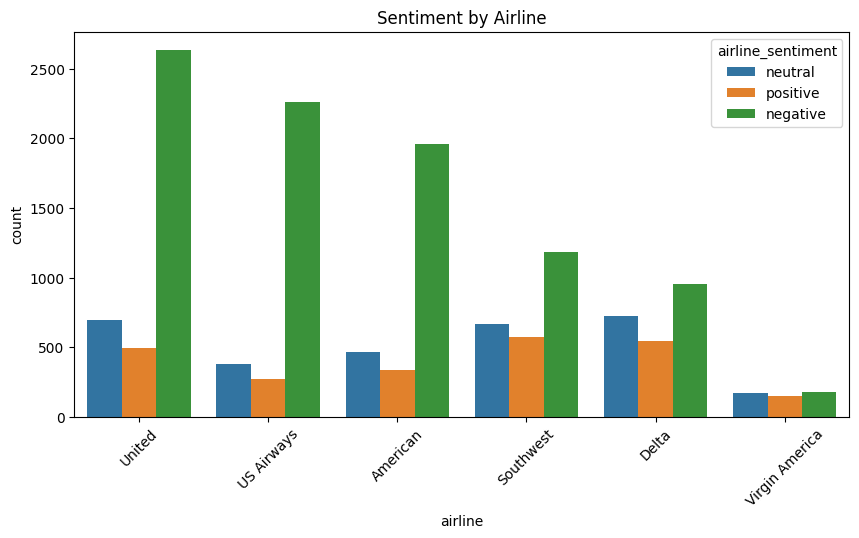

In [63]:
# Airline-wise sentiment
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='airline', hue='airline_sentiment',
             order=df['airline'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Sentiment by Airline")
plt.show()

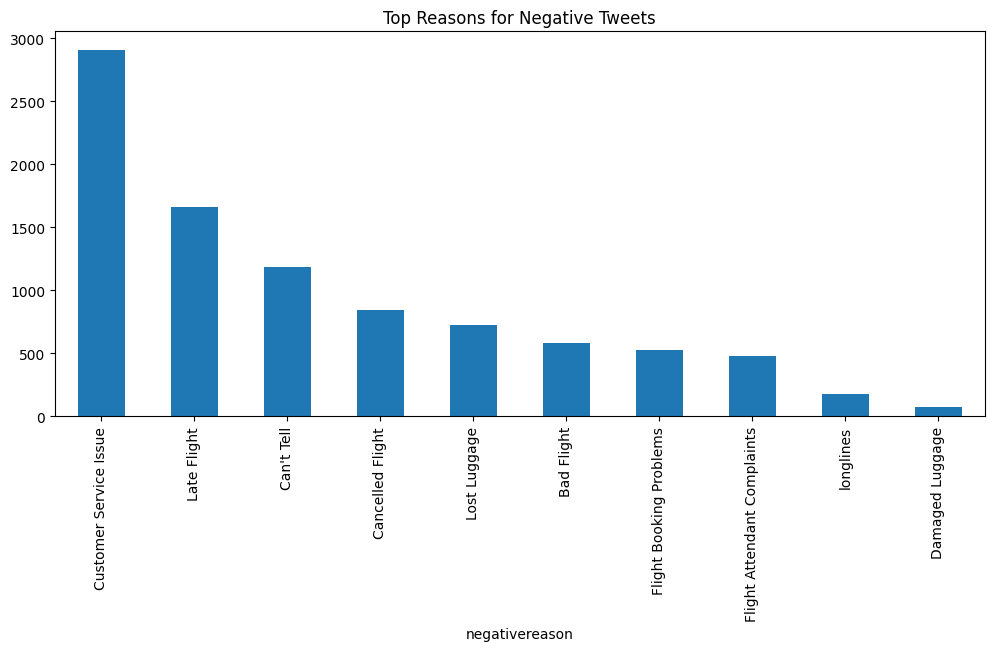

In [64]:
# Top negative reasons
if 'negativereason' in df:
    plt.figure(figsize=(12, 5))
    df[df['airline_sentiment'] == 'negative']['negativereason'].value_counts().plot(kind='bar')
    plt.title("Top Reasons for Negative Tweets")
    plt.show()

**Feature Engineering (Advanced)**

In [65]:
# text based features
df['has_question']=df['cleaned_text'].str.contains('\?').astype(int)
df['has_exclamation']=df['cleaned_text'].str.contains('\!').astype(int)

# 2. Sentiment lexicon scores (using VADER)

In [66]:
import nltk

# Download the VADER lexicon
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [67]:
df['vader_score']=df['cleaned_text'].apply(lambda x: sid.polarity_scores(x)['compound'])

<Axes: xlabel='hour'>

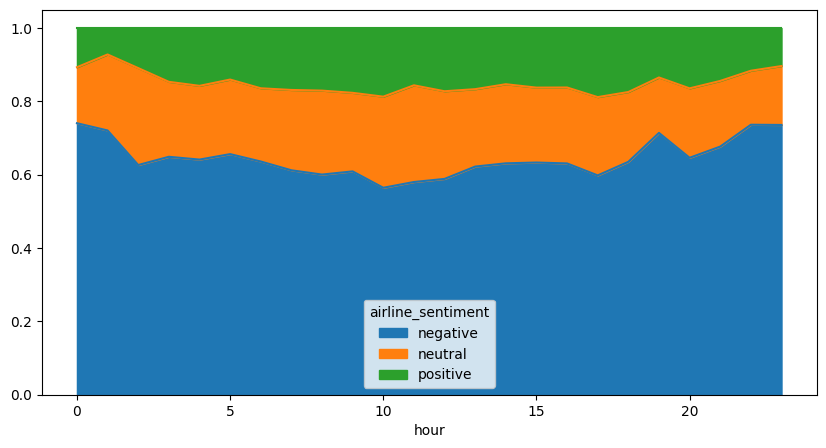

In [68]:
# 3. Time-based aggregations
df['tweet_created'] = pd.to_datetime(df['tweet_created'])
df['hour'] = df['tweet_created'].dt.hour
hourly_sentiment = df.groupby('hour')['airline_sentiment'].value_counts(normalize=True).unstack()
hourly_sentiment.plot(kind='area', stacked=True, figsize=(10, 5))

In [69]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,...,tweet_day_of_week,mentions_VirginAmerica,mentions_United,mentions_Southwest,mentions_Delta,mentions_American,has_question,has_exclamation,vader_score,hour
0,570306133677760513,neutral,1.0000,Not Specified,0.0000,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52-08:00,...,Tuesday,1,0,0,0,0,0,0,0.0000,11
1,570301130888122368,positive,0.3486,Not Specified,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59-08:00,...,Tuesday,1,0,0,0,0,0,0,0.0000,11
2,570301083672813571,neutral,0.6837,Not Specified,0.0000,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48-08:00,...,Tuesday,1,0,0,0,0,0,1,0.0000,11
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36-08:00,...,Tuesday,1,0,0,0,0,0,0,-0.2716,11
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45-08:00,...,Tuesday,1,0,0,0,0,0,0,-0.5829,11


# TRADITIONAL ML (LOGISTIC REGRESSION)

In [70]:


# Encode label
le = LabelEncoder()
y = le.fit_transform(df['airline_sentiment'])  # Positive = 2, Negative = 0, Neutral = 1

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X_text = tfidf.fit_transform(df['cleaned_text'])

# Numeric + Categorical Features
X_meta = df[['retweet_count', 'tweet_length', 'tweet_hour']].copy()
X_meta['tweet_day_of_week'] = LabelEncoder().fit_transform(df['tweet_day_of_week'])
X_meta['airline'] = LabelEncoder().fit_transform(df['airline'])

# Scale numerical features
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)

# Combine all features
X_full = hstack([X_text, X_meta_scaled])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)

# Predict & evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

    negative       0.81      0.92      0.87      1835
     neutral       0.64      0.54      0.59       620
    positive       0.81      0.55      0.65       473

    accuracy                           0.78      2928
   macro avg       0.76      0.67      0.70      2928
weighted avg       0.78      0.78      0.77      2928



prpeare lable column

In [71]:
# convert sentimnet to numericals
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()
df['sentiment_label']=le.fit_transform(df['airline_sentiment'])


In [72]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,...,mentions_VirginAmerica,mentions_United,mentions_Southwest,mentions_Delta,mentions_American,has_question,has_exclamation,vader_score,hour,sentiment_label
0,570306133677760513,neutral,1.0000,Not Specified,0.0000,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52-08:00,...,1,0,0,0,0,0,0,0.0000,11,1
1,570301130888122368,positive,0.3486,Not Specified,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59-08:00,...,1,0,0,0,0,0,0,0.0000,11,2
2,570301083672813571,neutral,0.6837,Not Specified,0.0000,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48-08:00,...,1,0,0,0,0,0,1,0.0000,11,1
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36-08:00,...,1,0,0,0,0,0,0,-0.2716,11,0
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45-08:00,...,1,0,0,0,0,0,0,-0.5829,11,0


In [77]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

# DEEP LEARNING LSTM

In [78]:


# Tokenization
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_text'])
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])
padded = pad_sequences(sequences, maxlen=100)

# Label encoding
le = LabelEncoder()
y = le.fit_transform(df['airline_sentiment'])  # Positive = 2, Negative = 0, Neutral = 1

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    padded, y, test_size=0.2, random_state=42, stratify=y
)

# Model
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),
    Bidirectional(LSTM(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.2)),
    Dropout(0.5),
    Dense(3, activation='softmax', kernel_regularizer=regularizers.l2(0.01))
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Training
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# Final evaluation
loss, acc = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {acc*100:.2f}%")


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 100, 128)          1280000   
                                                                 
 bidirectional (Bidirection  (None, 128)               98816     
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 3)                 387       
                                                                 
Total params: 1379203 (5.26 MB)
Trainable params: 1379203 (5.26 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
366/366 [==============================] - 97s 252ms/step - loss: 0.725